# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
# ! pip install pandas
# ! Pip install numpy
# ! pip install seaborn

In [2]:
import numpy as np
import seaborn as sns
import pandas as pd

Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

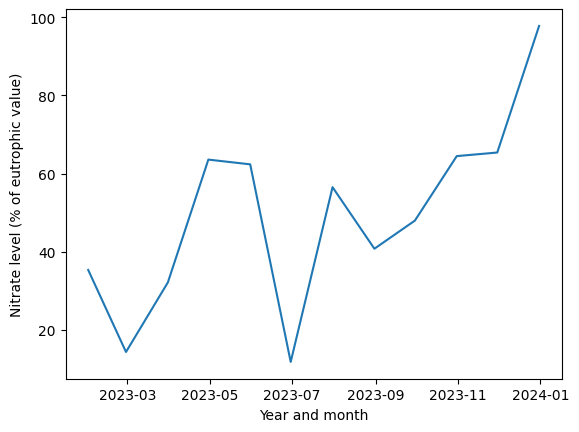

In [3]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

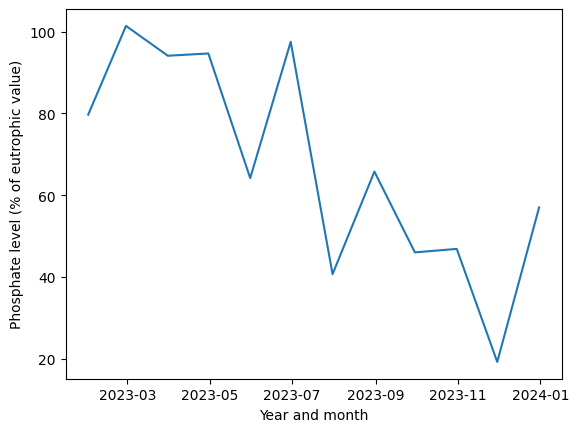

In [4]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

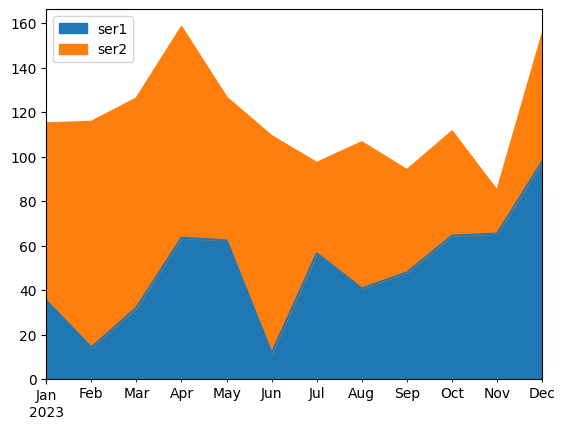

In [5]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  

Advantage: plotting them together puts less mental load on the audience when they try to compare the two

Disadvantage: are plot may not be as intuitive to many audiences, thus creating more mental load. Especially if presenting to an unfamiliar audience, there's also a high chance of it being misinterpreted - such as thinking the data is stacked/cumulative

How would you adjust the graphs shown to improve the presentation?
Are plot: legend isn't particuarly helpful - audience wouldn't know which ser corresponds to nitrate vs. phosphate. need to add a label to the y axis
Line plots: may be more helpful to combine them since they both use the same metric, depending on the audience adding "o" markers may make it easier to follow visually


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

Census Data
General thoughts
37 columns, 74k rows decent amount of data - shows breakdown of gender, age (voting age to differentiate adult vs. child), income, and race which will tie in well with my other datasets
Each tract is for a small area within a county - looks like there is county data for all 52 states, DC, and Puerto Rico
Looking at describe, it seems like some columns may have missing data, will need to look further into that. Looking at info, seems like most columns have at least 72k lines, which is still a decent amount to work with.
I think the race columns are percentages

Analysis Process
Looked at the data
Dropped na values into a new dataset, shape became 72718, 37
Checked the new df for dups, thankfully there weren't any
Start with univariate analysis:
    Histograms: men, women, race/ethnicity subplots, voting age citizen
    Boxplots: income (we haven't looked at this yet, diabetes dataset has income info) and total population

Conclusions
Histograms:
    Gender: men and women histograms both had right skew. Taking a quick glance at the data, it makes sense - this is regional data, so we wouldn't expect the counts to be incredibly high
    Race/Ethnicity: super heavy left skew for white people (there are WAY more white people than any other race); native/pacific hists looks like they only have 1 maybe 2 bars; hispanic, asian, and black are right skewed and have a lot more of a distribution than native/pacific
    Voting Age Citizen: since voting age is 18, I titled this regarding being an adult. Still has a bit of a right skew, but much more normal a distribution than the other histograms we looked at. Looks clustered around 3k.
Box plots:
    Income: super big right skew! lots of rich people reprersented here, but mostly middle income (in today's economy at least lol, would need to find a source if I use this);
            whisker is clustered pretty low still (maybe 8k?); some of the values are VERY high will need to look at the state/county and total pop (could be a good bivariate analyssis)

In [8]:
# load the data
census_df = pd.read_csv("acs2017_census_tract_data.csv",sep=",")

# look at the data
census_df.head()

,TractId,State,County,TotalPop,Men,Women,Hispanic,White,Black,Native,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
0,1001020100,Alabama,Autauga County,1845,899,946,2.4,86.3,5.2,0.0,...,0.5,0.0,2.1,24.5,881,74.2,21.2,4.5,0.0,4.6
1,1001020200,Alabama,Autauga County,2172,1167,1005,1.1,41.6,54.5,0.0,...,0.0,0.5,0.0,22.2,852,75.9,15.0,9.0,0.0,3.4
2,1001020300,Alabama,Autauga County,3385,1533,1852,8.0,61.4,26.5,0.6,...,1.0,0.8,1.5,23.1,1482,73.3,21.1,4.8,0.7,4.7
3,1001020400,Alabama,Autauga County,4267,2001,2266,9.6,80.3,7.1,0.5,...,1.5,2.9,2.1,25.9,1849,75.8,19.7,4.5,0.0,6.1
4,1001020500,Alabama,Autauga County,9965,5054,4911,0.9,77.5,16.4,0.0,...,0.8,0.3,0.7,21.0,4787,71.4,24.1,4.5,0.0,2.3


In [9]:
census_df.describe()

,TractId,TotalPop,Men,Women,Hispanic,White,Black,Native,Asian,Pacific,...,Walk,OtherTransp,WorkAtHome,MeanCommute,Employed,PrivateWork,PublicWork,SelfEmployed,FamilyWork,Unemployment
count,7.400100e+04,74001.000000,74001.000000,74001.000000,73305.000000,73305.000000,73305.00000,73305.000000,73305.000000,73305.000000,...,73200.000000,73200.000000,73200.000000,73055.000000,74001.000000,73190.000000,73190.000000,73190.000000,73190.000000,73191.000000
mean,2.839113e+10,4384.716017,2157.710707,2227.005311,17.265444,61.309043,13.28910,0.734047,4.753691,0.147341,...,3.042825,1.894605,4.661466,26.056594,2049.152052,79.494222,14.163342,6.171484,0.171164,7.246738
std,1.647593e+10,2228.936729,1120.560504,1146.240218,23.073811,30.634461,21.60118,4.554247,8.999888,1.029250,...,5.805753,2.549374,4.014940,7.124524,1138.865457,8.126383,7.328680,3.932364,0.456580,5.227624
min,1.001020e+09,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.303901e+10,2903.000000,1416.000000,1465.000000,2.600000,38.000000,0.80000,0.000000,0.200000,0.000000,...,0.400000,0.400000,2.000000,21.100000,1276.000000,75.200000,9.300000,3.500000,0.000000,3.900000
50%,2.804700e+10,4105.000000,2007.000000,2082.000000,7.400000,70.400000,3.80000,0.000000,1.500000,0.000000,...,1.400000,1.200000,3.800000,25.400000,1895.000000,80.600000,13.000000,5.500000,0.000000,6.000000
75%,4.200341e+10,5506.000000,2707.000000,2803.000000,21.100000,87.700000,14.60000,0.400000,5.000000,0.000000,...,3.300000,2.500000,6.300000,30.300000,2635.000000,85.000000,17.600000,8.000000,0.000000,9.000000
max,7.215375e+10,65528.000000,32266.000000,33262.000000,100.000000,100.000000,100.00000,100.000000,100.000000,71.900000,...,100.000000,100.000000,100.000000,73.900000,28945.000000,100.000000,100.000000,100.000000,22.300000,100.000000


In [11]:
census_df.shape

(74001, 37)

In [12]:
census_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74001 entries, 0 to 74000
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TractId           74001 non-null  int64  
 1   State             74001 non-null  str    
 2   County            74001 non-null  str    
 3   TotalPop          74001 non-null  int64  
 4   Men               74001 non-null  int64  
 5   Women             74001 non-null  int64  
 6   Hispanic          73305 non-null  float64
 7   White             73305 non-null  float64
 8   Black             73305 non-null  float64
 9   Native            73305 non-null  float64
 10  Asian             73305 non-null  float64
 11  Pacific           73305 non-null  float64
 12  VotingAgeCitizen  74001 non-null  int64  
 13  Income            72885 non-null  float64
 14  IncomeErr         72885 non-null  float64
 15  IncomePerCap      73256 non-null  float64
 16  IncomePerCapErr   73256 non-null  float64
 17  Pove

In [15]:
# look at the missing data (saw above that most of the data seems intact, but several categories with only 72k lines not 74k)
census_df.isnull().sum().sort_values()

TractId                0
State                  0
County                 0
TotalPop               0
Men                    0
Women                  0
VotingAgeCitizen       0
Employed               0
White                696
Black                696
Asian                696
Native               696
Pacific              696
Hispanic             696
IncomePerCapErr      745
IncomePerCap         745
Carpool              801
Transit              801
OtherTransp          801
WorkAtHome           801
Drive                801
Walk                 801
Unemployment         810
Service              811
Professional         811
Construction         811
Production           811
FamilyWork           811
PublicWork           811
SelfEmployed         811
PrivateWork          811
Office               811
Poverty              842
MeanCommute          946
ChildPoverty        1110
IncomeErr           1116
Income              1116
dtype: int64

In [16]:
# lets drop the rows without data
# reminder: .dropna(inplace=True) would modify the original df, I want to keep that in place in case I make a mistake
cesus_clean = census_df.dropna()

# look at the shape of the new df
cesus_clean.shape

(72718, 37)

In [ ]:
# now check for duplicates
cesus_clean.duplicated().sum()


np.int64(0)

In [ ]:
# ! pip install matplotlib
# ! pip install seaborn
import matplotlib.pyplot as plt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


Text(0.5, 1.0, 'Distribution of men per region')

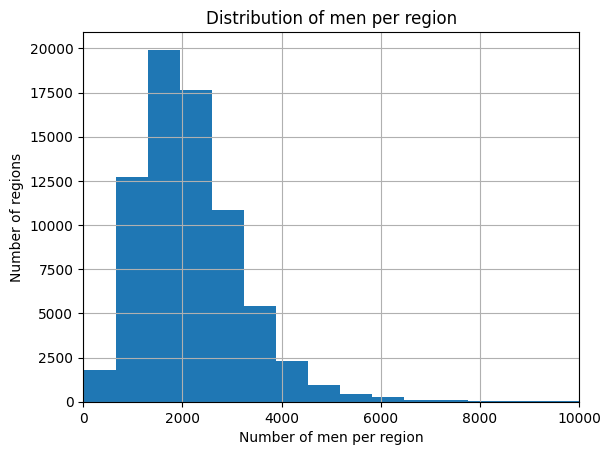

In [ ]:
# focus of topic is demographic data, so let's start by looking  at histograms for the sex
# when I first plotted without bins, the data only took up a very small space so adding in bins and xlim
# notive a heavy right skew
cesus_clean.hist("Men", bins=50)
plt.xlim(0,10000)
plt.xlabel("Number of men per region")
plt.ylabel("Number of regions with that amount of men")
plt.title("Distribution of men per region")

Text(0.5, 1.0, 'Distribution of women per region')

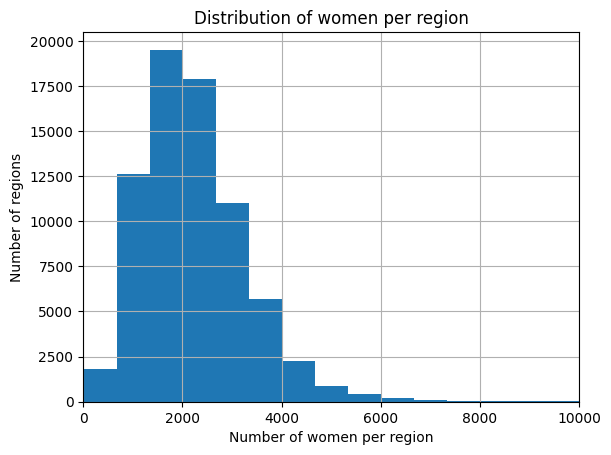

In [ ]:
# now look at the women
# also has a right skew
cesus_clean.hist("Women", bins=50)
plt.xlim(0,10000)
plt.xlabel("Number of women per region")
plt.ylabel("Number of regions with that amount of women")
plt.title("Distribution of women per region")

In [29]:
cesus_clean.columns

Index(['TractId', 'State', 'County', 'TotalPop', 'Men', 'Women', 'Hispanic',
       'White', 'Black', 'Native', 'Asian', 'Pacific', 'VotingAgeCitizen',
       'Income', 'IncomeErr', 'IncomePerCap', 'IncomePerCapErr', 'Poverty',
       'ChildPoverty', 'Professional', 'Service', 'Office', 'Construction',
       'Production', 'Drive', 'Carpool', 'Transit', 'Walk', 'OtherTransp',
       'WorkAtHome', 'MeanCommute', 'Employed', 'PrivateWork', 'PublicWork',
       'SelfEmployed', 'FamilyWork', 'Unemployment'],
      dtype='str')

Text(0, 0.5, 'Number of regions within the percentage')

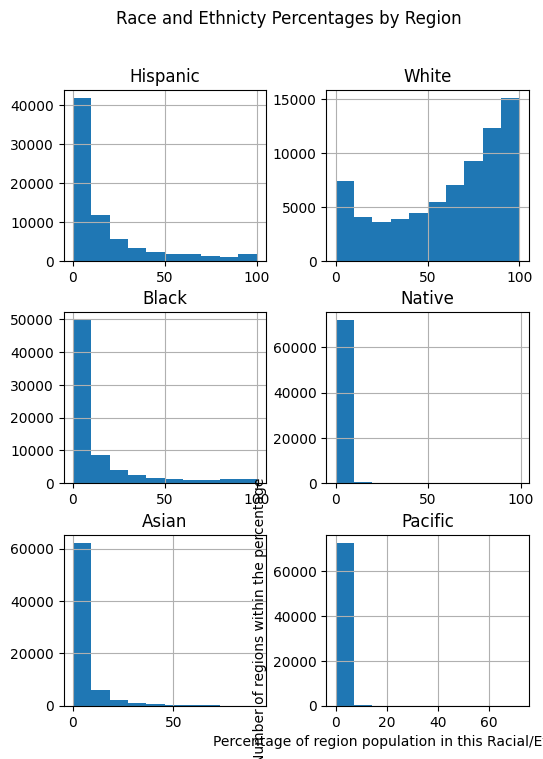

In [ ]:
# lets look at the race/ethnicity columns next
# 'Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific'
cesus_clean[['Hispanic', 'White', 'Black', 'Native', 'Asian', 'Pacific']].hist()
plt.suptitle("Race and Ethnicty Percentages by Region")
plt.xlabel("Percentage of region population in this Racial/Ethnicity Group")
plt.ylabel("Number of regions within the percentage")
# labels are a bit off but I don't feel like fixing them right now
# lots of thoughts put those in the conclusions. tldr; lots of white peopel very few pacific/native, the rest all fall somewhere in between those groups

Text(0.5, 1.0, 'Distribution of adults per region')

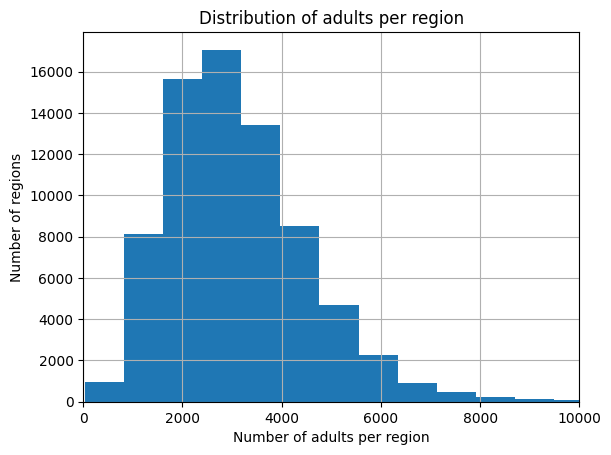

In [ ]:
# lastly, lets look at the voting age his to differentiate between adults and childen
cesus_clean.hist('VotingAgeCitizen', bins=50)
plt.xlim(0,10000)
plt.xlabel("Number of adults per region")
plt.ylabel("Number of regions with that amount of adults")
plt.title("Distribution of adults per region")
# still has a bit of a right skew, but much more normal a distribution than the other histograms we looked at

Text(0.5, 0, 'Income')

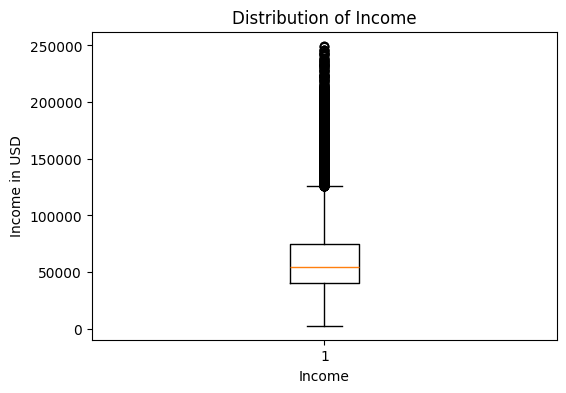

In [47]:
# income box plot 'Income'
# reference: https://statisticsbyjim.com/graphs/box-plot/
plt.figure(figsize=(6,4))
plt.boxplot(cesus_clean['Income'])
plt.title("Distribution of Income")
plt.ylabel("Income in USD")
plt.xlabel("Income")
# super big right skew! lots of rich people reprersented here, but mostly middle income (in today's economy at least lol, would need to find a source if I use this)

Text(0.5, 0, 'Population')

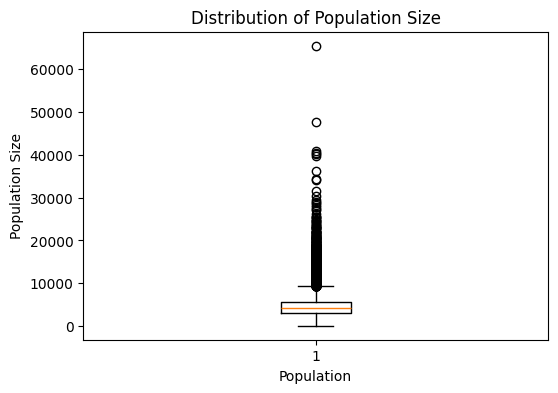

In [ ]:
# total population box plot 'TotalPop'
plt.figure(figsize=(6,4))
plt.boxplot(cesus_clean['TotalPop'])
plt.title("Distribution of Population Size")
plt.ylabel("Population Size")
plt.xlabel("Population")
# also has a right skew, middle 50% are pretty low (maybe around 3k?), whisker is clustered pretty low still (maybe 8k?); some of the values are VERY high will need to look at the state/county and total pop (could be a good bivariate analyssis)

Life Expectancy Data

Conclusions

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

In [6]:
# my book uses different page numbers, so I hope I picked one in the correct section. Attemptiong figure 3.23
# visual inspection 1 plot with 2 lines for received and processed. no markers and each has a different color. yearly data

# set the variables
# x_plot = [Jan, Feb, Mar, Apr, May, Jun, Jul, Aug, Sep, Oct, Nov, Dec]
y_proc = [160, 180, 240, 140, 170, 130, 120, 170, 130, 110, 120, 140]
y_rec = [160, 180, 250]